In [ ]:
import pandas as pd
import sys
import os
import matplotlib.pyplot as plt
import seaborn as sns

sys.path.insert(0, os.path.abspath('..'))

print("Пути:", sys.path[:2])
from src.data_loader import load_dataset

df = load_dataset(year=2007)

Пути: ['c:\\Users\\user\\Desktop\\pets\\recsys', 'C:\\Users\\user\\AppData\\Local\\Programs\\Python\\Python312\\python312.zip']


In [3]:
df = load_dataset()

ТОП-10 СТРАН ПО КОЛИЧЕСТВУ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ
 1. United States: 228 пользователей
 2. United Kingdom: 126 пользователей
 3. Poland: 50 пользователей
 4. Germany: 36 пользователей
 5. Norway: 35 пользователей
 6. Canada: 32 пользователей
 7. Finland: 32 пользователей
 8. Turkey: 28 пользователей
 9. Italy: 27 пользователей
10. Sweden: 24 пользователей


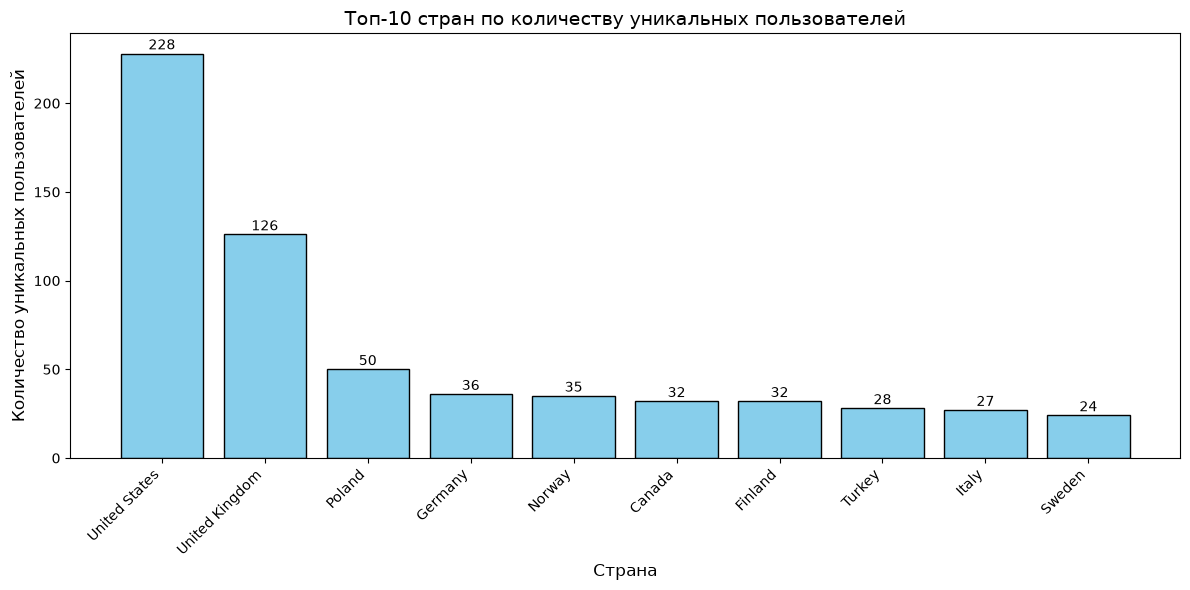

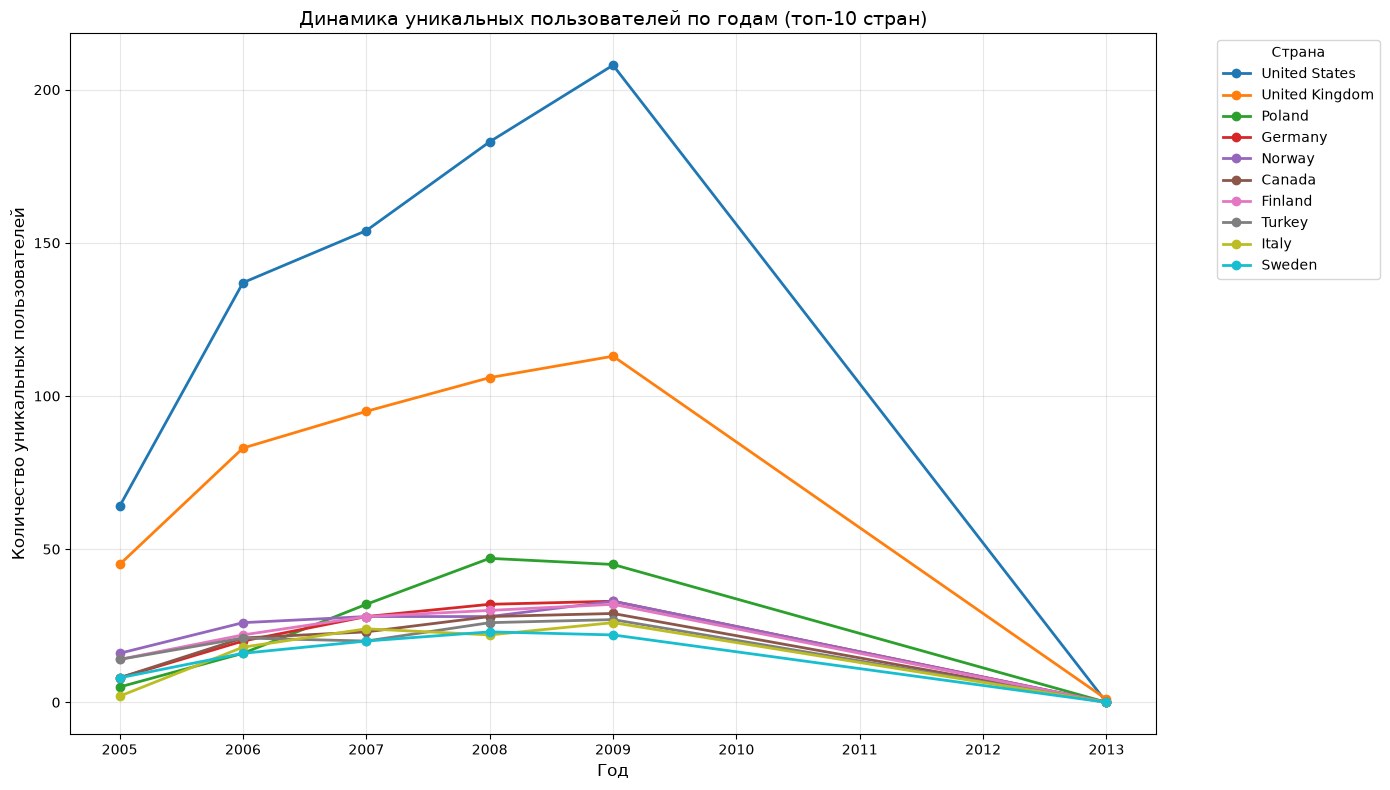

<Figure size 1400x800 with 0 Axes>

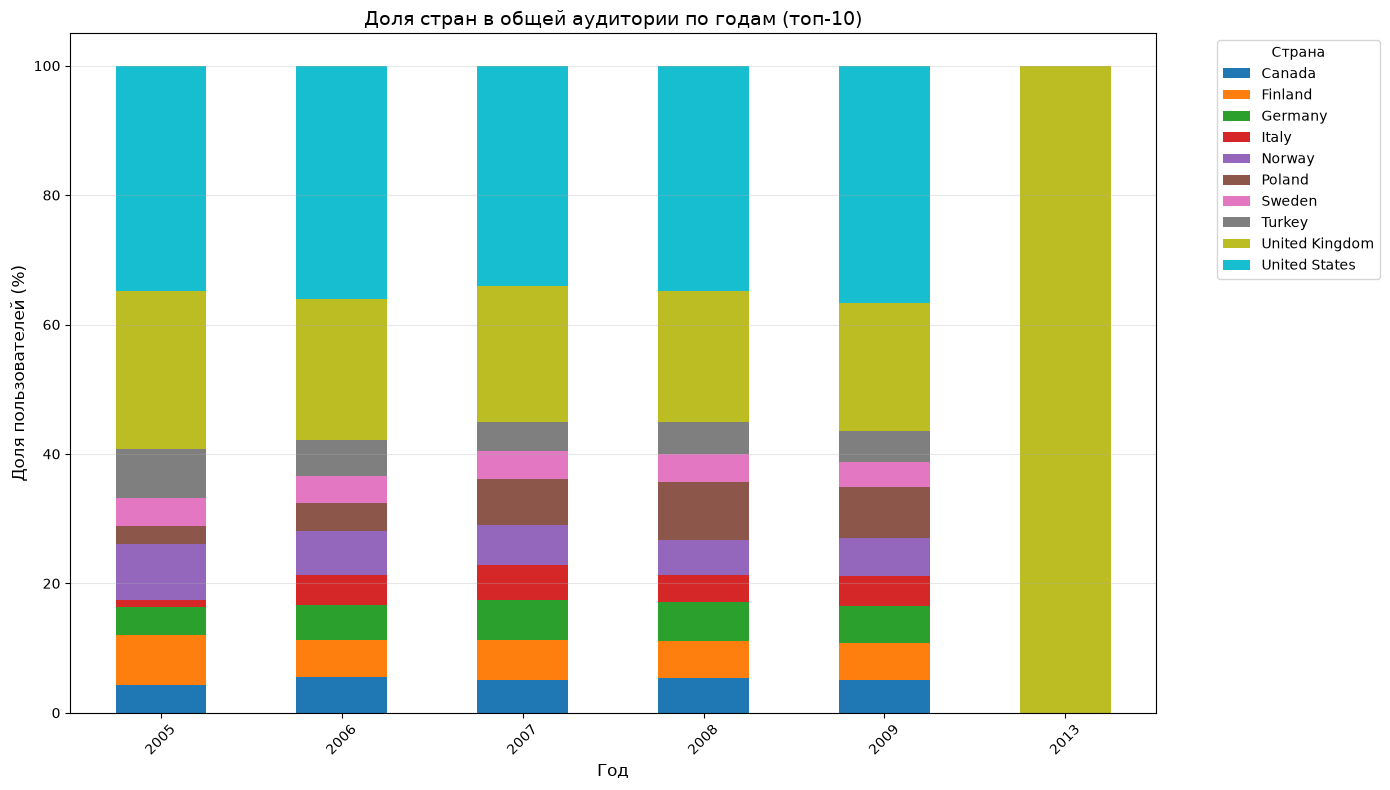


КОЛИЧЕСТВО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ ПО ГОДАМ (ТОП-10 СТРАН)
country  Canada  Finland  Germany  Italy  Norway  Poland  Sweden  Turkey  \
year                                                                       
2005          8       14        8      2      16       5       8      14   
2006         21       22       20     18      26      16      16      21   
2007         23       28       28     24      28      32      20      20   
2008         28       30       32     22      28      47      23      26   
2009         29       32       33     26      33      45      22      27   
2013          0        0        0      0       0       0       0       0   

country  United Kingdom  United States  
year                                    
2005                 45             64  
2006                 83            137  
2007                 95            154  
2008                106            183  
2009                113            208  
2013                  1              0  

✅

In [ ]:
# ============================================================
# 1. ТОП-10 СТРАН ПО КОЛИЧЕСТВУ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================================

# Считаем уникальных пользователей по странам
country_users = df.groupby('country')['user_id'].nunique().sort_values(ascending=False)

# Берем топ-10
top10_countries = country_users.head(10)

print("="*70)
print("ТОП-10 СТРАН ПО КОЛИЧЕСТВУ УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ")
print("="*70)
for i, (country, count) in enumerate(top10_countries.items(), 1):
    print(f"{i:2d}. {country}: {count} пользователей")

# ============================================================
# 2. ГРАФИК 1: ТОП-10 СТРАН (СТОЛБЦЫ)
# ============================================================

plt.figure(figsize=(12, 6))
bars = plt.bar(top10_countries.index, top10_countries.values, color='skyblue', edgecolor='black')
plt.title('Топ-10 стран по количеству уникальных пользователей', fontsize=14)
plt.xlabel('Страна', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.xticks(rotation=45, ha='right')

# Подписываем значения на столбцах
for bar, count in zip(bars, top10_countries.values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5, 
             str(count), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

# ============================================================
# 3. ПОДГОТОВКА ДАННЫХ ДЛЯ ДИНАМИКИ ПО ГОДАМ
# ============================================================

# Извлекаем год из timestamp или даты регистрации
# Если есть колонка 'timestamp' — используем её
if 'timestamp' in df.columns:
    df['year'] = pd.to_datetime(df['timestamp'], unit='s').dt.year
elif 'signup_date' in df.columns:
    df['year'] = pd.to_datetime(df['signup_date']).dt.year
else:
    # Если нет даты — можно по году регистрации
    df['year'] = pd.to_datetime(df['date']).dt.year

# Фильтруем только топ-10 стран
df_top10 = df[df['country'].isin(top10_countries.index)]

# Группируем: страна + год → уникальные пользователи
yearly_users = df_top10.groupby(['country', 'year'])['user_id'].nunique().reset_index()

# Создаем сводную таблицу: страны → годы
pivot_yearly = yearly_users.pivot(index='year', columns='country', values='user_id').fillna(0)

# Сортируем по годам
pivot_yearly = pivot_yearly.sort_index()

# ============================================================
# 4. ГРАФИК 2: ДИНАМИКА УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ ПО ГОДАМ
# ============================================================

plt.figure(figsize=(14, 8))

# Линии для каждой страны
for country in top10_countries.index:
    plt.plot(pivot_yearly.index, pivot_yearly[country], 
             marker='o', linewidth=2, markersize=6, label=country)

plt.title('Динамика уникальных пользователей по годам (топ-10 стран)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Количество уникальных пользователей', fontsize=12)
plt.legend(title='Страна', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# ============================================================
# 5. ДОПОЛНИТЕЛЬНО: СТЕКОВАЯ ДИАГРАММА (доля каждой страны по годам)
# ============================================================

plt.figure(figsize=(14, 8))

# Нормализуем по годам (доли)
pivot_yearly_pct = pivot_yearly.div(pivot_yearly.sum(axis=1), axis=0) * 100

pivot_yearly_pct.plot(kind='bar', stacked=True, figsize=(14, 8), colormap='tab10')
plt.title('Доля стран в общей аудитории по годам (топ-10)', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.legend(title='Страна', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 6. ВЫВОД ТАБЛИЦЫ (по годам)
# ============================================================

print("\n" + "="*70)
print("КОЛИЧЕСТВО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ ПО ГОДАМ (ТОП-10 СТРАН)")
print("="*70)
print(pivot_yearly.astype(int))

# Сохраняем в CSV
pivot_yearly.to_csv('users_by_country_year.csv')
print("\n✅ Таблица сохранена в 'users_by_country_year.csv'")

КОЛИЧЕСТВО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ ПО ПОЛУ И ГОДАМ
gender  female  male
year                
2005        66   140
2006       218   290
2007       284   354
2008       326   420
2009       346   461
2010         1     0
2013         1     0


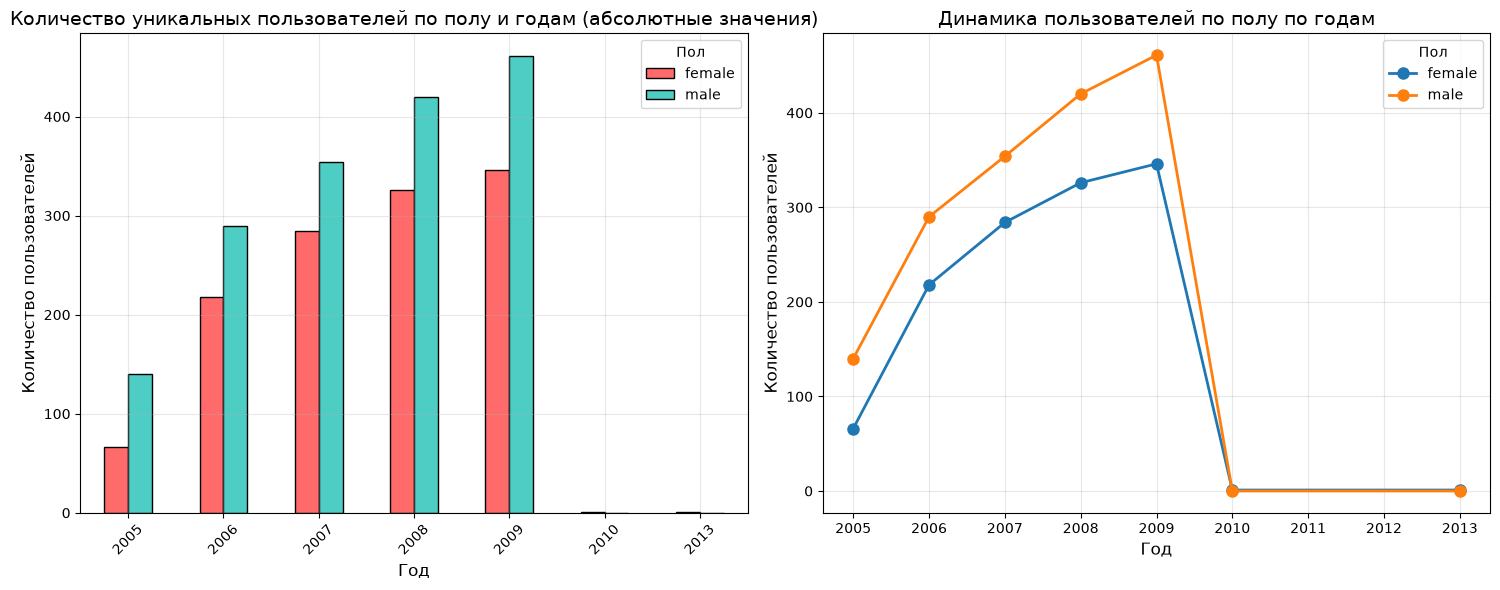


ИТОГОВАЯ ТАБЛИЦА
gender  female  male
year                
2005        66   140
2006       218   290
2007       284   354
2008       326   420
2009       346   461
2010         1     0
2013         1     0
Total     1242  1665

ОБЩЕЕ КОЛИЧЕСТВО ПОЛЬЗОВАТЕЛЕЙ ПО ПОЛУ
  female: 382 пользователей (43.2%)
  male: 502 пользователей (56.8%)


<Figure size 1200x600 with 0 Axes>

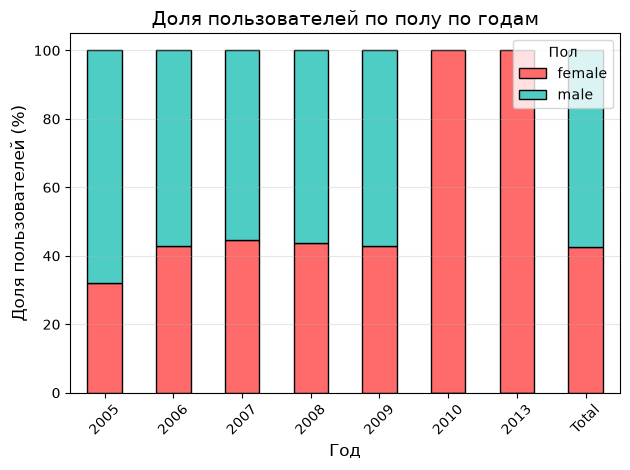


✅ Таблица сохранена в 'gender_by_year.csv'


In [5]:
# ============================================================
# 1. ПОДГОТОВКА ДАННЫХ
# ============================================================

# Убедимся, что у нас есть колонка с годом
if 'timestamp' in df.columns:
    df['year'] = pd.to_datetime(df['timestamp'], unit='s').dt.year
elif 'signup_date' in df.columns:
    df['year'] = pd.to_datetime(df['signup_date']).dt.year
else:
    # Если нет даты — пропускаем
    print("❌ Нет колонки с датой для определения года")
    exit()

# Убираем пустые значения пола
df_clean = df[df['gender'].notna()]

# ============================================================
# 2. ГРУППИРОВКА: ГОД × ПОЛ → КОЛИЧЕСТВО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================================

# Считаем уникальных пользователей по годам и полу
gender_by_year = df_clean.groupby(['year', 'gender'])['user_id'].nunique().reset_index()

# Создаем сводную таблицу: годы → столбцы (female, male)
gender_pivot = gender_by_year.pivot(index='year', columns='gender', values='user_id').fillna(0)

# Приводим к целым числам
gender_pivot = gender_pivot.astype(int)

print("="*70)
print("КОЛИЧЕСТВО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ ПО ПОЛУ И ГОДАМ")
print("="*70)
print(gender_pivot)

# ============================================================
# 3. ГРАФИК 1: СТОЛБЦЫ (absolute)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# График 1: Столбцы с группировкой по годам
gender_pivot.plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
axes[0].set_title('Количество уникальных пользователей по полу и годам (абсолютные значения)', fontsize=14)
axes[0].set_xlabel('Год', fontsize=12)
axes[0].set_ylabel('Количество пользователей', fontsize=12)
axes[0].legend(title='Пол')
axes[0].grid(True, alpha=0.3)
axes[0].tick_params(axis='x', rotation=45)

# График 2: Линии
for gender in gender_pivot.columns:
    axes[1].plot(gender_pivot.index, gender_pivot[gender], 
                 marker='o', linewidth=2, markersize=8, label=gender)

axes[1].set_title('Динамика пользователей по полу по годам', fontsize=14)
axes[1].set_xlabel('Год', fontsize=12)
axes[1].set_ylabel('Количество пользователей', fontsize=12)
axes[1].legend(title='Пол')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 4. ДОПОЛНИТЕЛЬНО: ТАБЛИЦА С ИТОГАМИ
# ============================================================

# Добавляем строку "Всего"
gender_pivot.loc['Total'] = gender_pivot.sum()

print("\n" + "="*70)
print("ИТОГОВАЯ ТАБЛИЦА")
print("="*70)
print(gender_pivot)

# ============================================================
# 5. СООТНОШЕНИЕ ПОЛОВ (доли)
# ============================================================

# Считаем общее количество по полу
total_by_gender = df_clean.groupby('gender')['user_id'].nunique()

print("\n" + "="*70)
print("ОБЩЕЕ КОЛИЧЕСТВО ПОЛЬЗОВАТЕЛЕЙ ПО ПОЛУ")
print("="*70)
for gender, count in total_by_gender.items():
    print(f"  {gender}: {count} пользователей ({count/total_by_gender.sum()*100:.1f}%)")

# ============================================================
# 6. ВИЗУАЛИЗАЦИЯ: ДОЛИ ПО ГОДАМ (stacked)
# ============================================================

# Нормализуем по годам (доли)
gender_pivot_pct = gender_pivot.div(gender_pivot.sum(axis=1), axis=0) * 100

plt.figure(figsize=(12, 6))
gender_pivot_pct.plot(kind='bar', stacked=True, color=['#FF6B6B', '#4ECDC4'], edgecolor='black')
plt.title('Доля пользователей по полу по годам', fontsize=14)
plt.xlabel('Год', fontsize=12)
plt.ylabel('Доля пользователей (%)', fontsize=12)
plt.legend(title='Пол')
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

# ============================================================
# 7. СОХРАНЯЕМ РЕЗУЛЬТАТ
# ============================================================

gender_pivot.to_csv('gender_by_year.csv')
print("\n✅ Таблица сохранена в 'gender_by_year.csv'")

In [37]:
df.columns

Index(['user_index', 'artist_index', 'track_index', 'user_id', 'timestamp',
       'musicbrainz_artist_id', 'artist_name', 'musicbrainz_track_id',
       'track_name', 'gender', 'age', 'country', 'signup_date', 'age_group'],
      dtype='object')

In [14]:
df['user_id'].nunique()

721

In [5]:
import numpy as np
# Активность пользователей за период
user_activity = df.groupby('user_id').size()

# Перцентили
percentiles = [0, 10, 25, 50, 75, 90, 95, 99, 100]
values = np.percentile(user_activity, percentiles)

print("📊 Перцентили по количеству прослушиваний:")
for p, v in zip(percentiles, values):
    print(f"  {p}%: {v:.0f}")

📊 Перцентили по количеству прослушиваний:
  0%: 1
  10%: 259
  25%: 1381
  50%: 4207
  75%: 9352
  90%: 15110
  95%: 19389
  99%: 31782
  100%: 54819


In [6]:
# фильтруем, чтобы слушатели всего подряд не создали шум

threshold = np.percentile(user_activity, 99)  # 31 782
filtered = df[df.groupby('user_id')['user_id'].transform('size') <= threshold]

In [7]:
filtered['track_name'].nunique()

366572

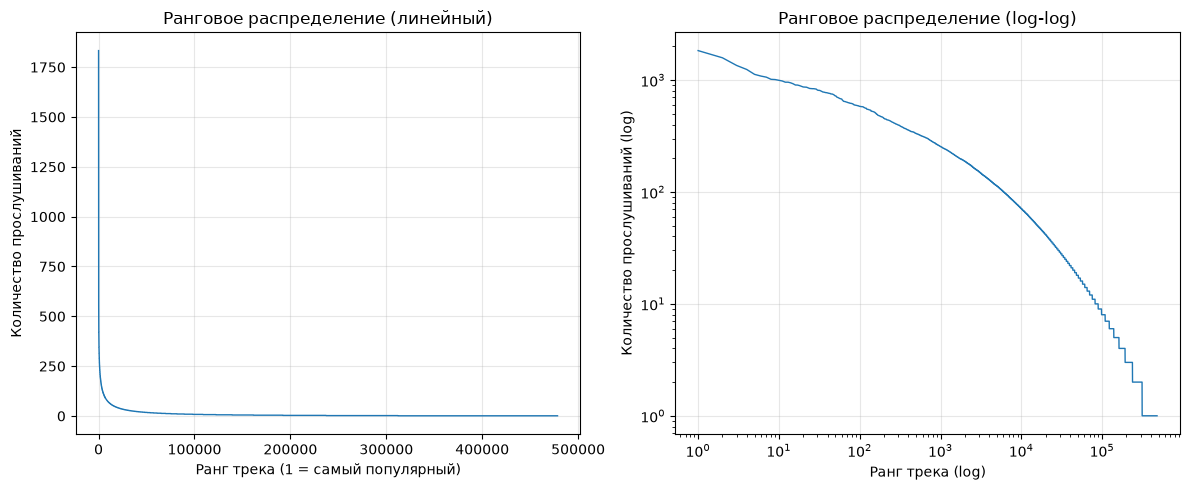

Топ-5 самых популярных треков:
  1. ('The Knife', 'Heartbeats'): 1833 прослушиваний
  2. ('Britney Spears', 'Gimme More'): 1581 прослушиваний
  3. ('The Killers', 'When You Were Young'): 1350 прослушиваний
  4. ('Mika', 'Grace Kelly'): 1243 прослушиваний
  5. ('Nelly Furtado', 'Say It Right'): 1124 прослушиваний


In [8]:
import matplotlib.pyplot as plt

# Считаем популярность и сортируем
popularity = filtered.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False)

# Строим график
plt.figure(figsize=(12, 5))

# Линейный масштаб
plt.subplot(1, 2, 1)
plt.plot(range(1, len(popularity) + 1), popularity.values, linewidth=1)
plt.xlabel('Ранг трека (1 = самый популярный)')
plt.ylabel('Количество прослушиваний')
plt.title('Ранговое распределение (линейный)')
plt.grid(True, alpha=0.3)

# Логарифмический масштаб (лучше видно)
plt.subplot(1, 2, 2)
plt.loglog(range(1, len(popularity) + 1), popularity.values, linewidth=1)
plt.xlabel('Ранг трека (log)')
plt.ylabel('Количество прослушиваний (log)')
plt.title('Ранговое распределение (log-log)')
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Выводим топ-5
print("Топ-5 самых популярных треков:")
for i, (track, count) in enumerate(popularity.head(5).items(), 1):
    print(f"  {i}. {track}: {count} прослушиваний")

In [10]:
popularity = filtered.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False)

print(f"Количество уникальных пар (исполнитель + трек): {len(popularity):,}")
print(f"Тип popularity: {type(popularity)}")
print(f"Размерность: {popularity.shape}")
print(f"Первые 5 значений: {popularity.head().values}")
print(f"Последние 5 значений: {popularity.tail().values}")

# Проверяем, нет ли дубликатов в индексе
print(f"Уникальных индексов: {popularity.index.nunique()}")

Количество уникальных пар (исполнитель + трек): 478,509
Тип popularity: <class 'pandas.core.series.Series'>
Размерность: (478509,)
Первые 5 значений: [1833 1581 1350 1243 1124]
Последние 5 значений: [1 1 1 1 1]
Уникальных индексов: 478509


In [12]:
result = filtered.groupby('artist_name')['user_id'].nunique().reset_index()
result = result.sort_values('user_id', ascending=False)
print(result)

                 artist_name  user_id
30788              Radiohead      423
37265            The Beatles      360
31182  Red Hot Chili Peppers      336
40543      The White Stripes      325
37783               The Cure      325
...                      ...      ...
45128                    陳小春        1
45129                    陳慧琳        1
45130                    陳綺貞        1
45140                  高松美砂絵        1
45138                    高木完        1

[45165 rows x 2 columns]


In [13]:
# Считаем уникальных слушателей для каждого исполнителя
artist_listeners = filtered.groupby('artist_name')['user_id'].nunique().reset_index()
artist_listeners.columns = ['artist_name', 'unique_listeners']

# Подсчёт количества исполнителей по порогам
thresholds = [1, 5, 50, 100]

for threshold in thresholds:
    count = (artist_listeners['unique_listeners'] > threshold).sum()
    print(f"Исполнителей с > {threshold} уникальных слушателей: {count:,}")

Исполнителей с > 1 уникальных слушателей: 22,757
Исполнителей с > 5 уникальных слушателей: 8,282
Исполнителей с > 50 уникальных слушателей: 951
Исполнителей с > 100 уникальных слушателей: 363


C:\Users\user\AppData\Local\Temp\ipykernel_9632\2321649549.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  filtered['date'] = pd.to_datetime(filtered['timestamp'], unit='s')


Топ-10 исполнителей:
1. Radiohead: 29,506 прослушиваний
2. The Beatles: 25,618 прослушиваний
3. The Knife: 20,520 прослушиваний


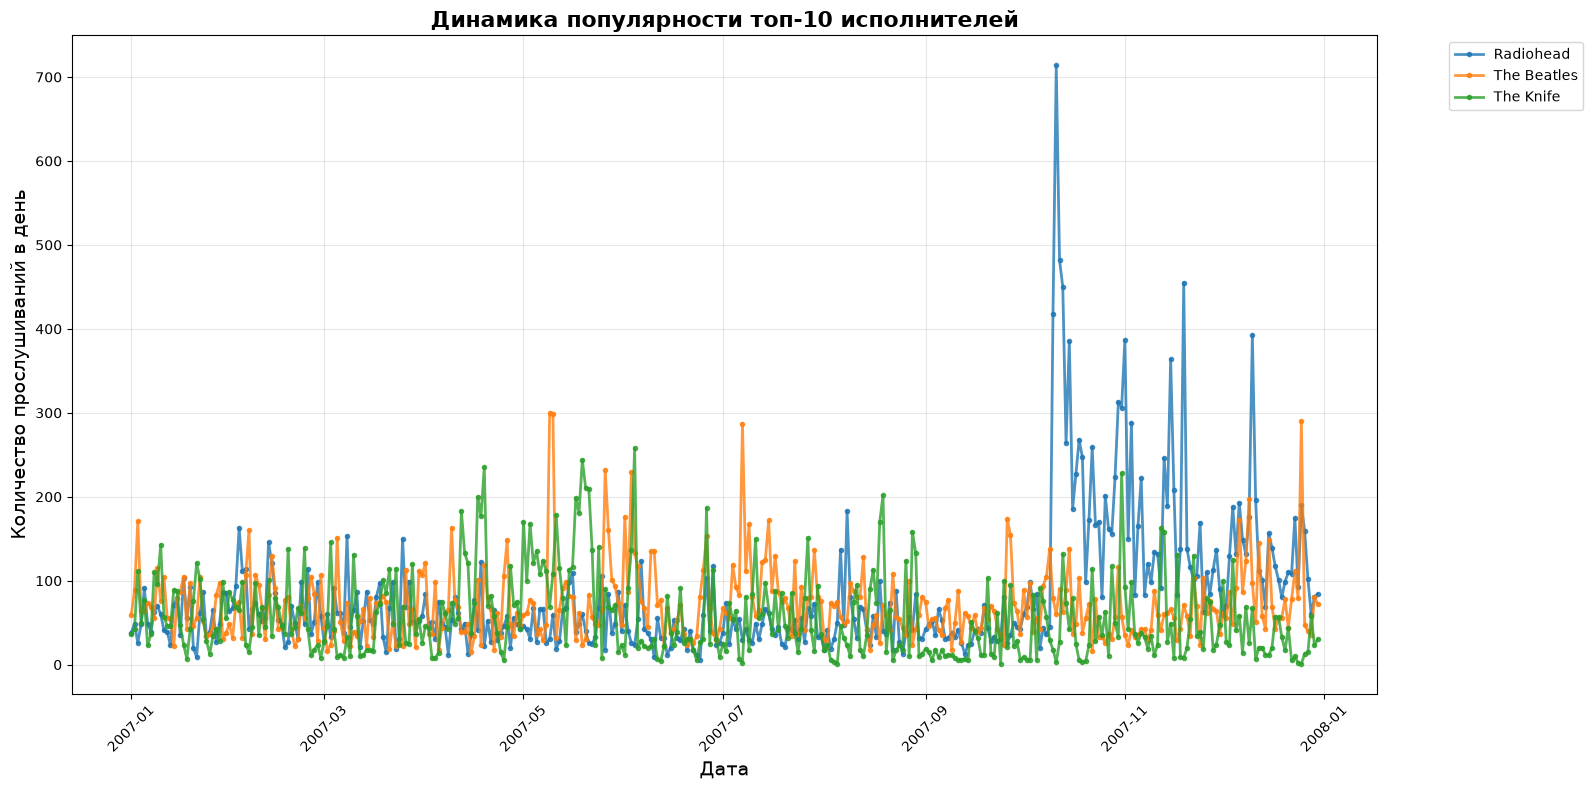

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Преобразуем timestamp в дату (если timestamp в секундах)
# Если timestamp в миллисекундах, замените 's' на 'ms'
filtered['date'] = pd.to_datetime(filtered['timestamp'], unit='s')

# 2. Находим топ-10 исполнителей по количеству прослушиваний
top_artists = filtered['artist_name'].value_counts().head(3).index.tolist()
print("Топ-10 исполнителей:")
for i, artist in enumerate(top_artists, 1):
    count = filtered[filtered['artist_name'] == artist].shape[0]
    print(f"{i}. {artist}: {count:,} прослушиваний")

# 3. Фильтруем данные только для топ-10 исполнителей
filtered_top = filtered[filtered['artist_name'].isin(top_artists)]

# 4. Группируем по дате и исполнителю
daily_listens = filtered_top.groupby([pd.Grouper(key='date', freq='D'), 'artist_name']).size().reset_index(name='listens')

# 5. Строим график
plt.figure(figsize=(16, 8))

# Цветовая палитра
colors = sns.color_palette("tab10", 10)

for i, artist in enumerate(top_artists):
    artist_data = daily_listens[daily_listens['artist_name'] == artist]
    plt.plot(artist_data['date'], 
             artist_data['listens'], 
             label=artist, 
             color=colors[i],
             linewidth=2,
             marker='o',
             markersize=3,
             alpha=0.8)

plt.xlabel('Дата', fontsize=14)
plt.ylabel('Количество прослушиваний в день', fontsize=14)
plt.title('Динамика популярности топ-10 исполнителей', fontsize=16, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=10)
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd
import numpy as np
from src.data_loader import load_dataset


def hit_rate(recs, actual):
    """Есть ли хотя бы одно совпадение."""
    actual_set = set(actual)
    hits = sum(1 for track in recs if track in actual_set)
    return 1 if hits > 0 else 0

train_end = '2007-12-24'
test_start = '2007-12-25'

df_train = df[df['timestamp'] <= train_end]
df_test = df[(df['timestamp'] >= test_start)]

# Глобальный топ-100
global_top = df_train.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False).head(100).index.tolist()
popular_recs = global_top[:10]

results = []

for user_id in df_test['user_id'].unique():
    user_tracks = df_train[df_train['user_id'] == user_id]
    user_top = user_tracks.groupby(['artist_name', 'track_name']).size().sort_values(ascending=False).head(50).index.tolist()
    
    overlap = len(set(user_top) & set(global_top))
    overlap_ratio = overlap / len(user_top) if user_top else 0
    
    actual = df_test[df_test['user_id'] == user_id][['artist_name', 'track_name']].itertuples(index=False, name=None)
    hit = hit_rate(popular_recs, actual)
    
    results.append({
        'user_id': user_id,
        'overlap_ratio': overlap_ratio,
        'hit_popular': hit
    })

df_results = pd.DataFrame(results)

popular_group = df_results[df_results['overlap_ratio'] > 0.3]
not_popular_group = df_results[df_results['overlap_ratio'] <= 0.3]

print("\n" + "=" * 60)
print("📊 Анализ стратегии Popular")
print("=" * 60)

print(f"\n👥 Всего пользователей: {len(df_results)}")
print(f"  >30% пересечения: {len(popular_group)} ({len(popular_group)/len(df_results)*100:.1f}%)")
print(f"  <=30% пересечения: {len(not_popular_group)} ({len(not_popular_group)/len(df_results)*100:.1f}%)")

print(f"\n📊 Hit Rate Popular:")
print(f"  Группа >30%: {popular_group['hit_popular'].mean():.2%}")
print(f"  Группа <=30%: {not_popular_group['hit_popular'].mean():.2%}")


📊 Анализ стратегии Popular

👥 Всего пользователей: 430
  >30% пересечения: 0 (0.0%)
  <=30% пересечения: 430 (100.0%)

📊 Hit Rate Popular:
  Группа >30%: nan%
  Группа <=30%: 11.86%


In [33]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = df.drop_duplicates(subset=['user_id'])
df = df[df['country'].isin(df['country'].unique())]
df['country'] = df['country'].astype(str)
df = df.dropna(subset=['country', 'gender', 'age'])

bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)


grouped = df.groupby(['country', 'gender', 'age_group'], observed=True).size().reset_index(name='count')

# Создаём pivot
pivot = grouped.pivot_table(index='country', 
                            columns=['gender', 'age_group'], 
                            values='count', 
                            fill_value=0)


print("="*70)
print("PIVOT (только страны из датасета)")
print("="*70)
print(pivot)

print("\nСтраны в pivot:")
print(pivot.index.tolist())

print("\nСтраны в исходных данных:")
print(df['country'].unique().tolist())
extra = set(pivot.index) - set(df['country'].unique())
print(f"\nЛишние страны (которых нет в данных): {extra}")

PIVOT (только страны из датасета)
gender                               female                                \
age_group                              0-18 19-25 26-35 36-45 46-55 56-65   
country                                                                     
Argentina                               0.0   0.0   0.0   0.0   0.0   0.0   
Armenia                                 0.0   0.0   1.0   0.0   0.0   0.0   
Australia                               0.0   0.0   0.0   0.0   0.0   0.0   
Belgium                                 0.0   1.0   0.0   0.0   0.0   0.0   
Brazil                                  0.0   1.0   1.0   1.0   0.0   0.0   
British Indian Ocean Territory          0.0   0.0   0.0   0.0   0.0   0.0   
Canada                                  0.0   3.0   1.0   0.0   0.0   0.0   
Chile                                   0.0   0.0   0.0   0.0   0.0   0.0   
Croatia                                 1.0   1.0   0.0   0.0   0.0   0.0   
Czech Republic                          0.

C:\Users\user\AppData\Local\Temp\ipykernel_9632\511764273.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = grouped.pivot_table(index='country',


In [34]:
display(df[df['country'] == 'Argentina'])

,user_index,artist_index,track_index,user_id,timestamp,musicbrainz_artist_id,artist_name,musicbrainz_track_id,track_name,gender,age,country,signup_date,age_group
3406417,251,43780,855229,user_000252,2007-12-13 02:08:30,8538e728-ca0b-4321-b7e5-cff6565dd4c0,Depeche Mode,e40bead4-0f68-43c9-8c65-d6e404ecdfbc,It Doesn'T Matter,male,31.0,Argentina,2004-08-25,26-35
4032172,295,53667,227370,user_000298,2007-12-30 22:54:35,a371601f-c184-4683-806d-2eb35e88f0d7,All Saints,3c785094-944d-4f61-a9f2-e0c1b5ecd0cf,Scar,male,28.0,Argentina,2005-01-26,26-35
727275,352,7848,595001,user_000355,2007-12-25 20:37:18,17b53d9f-5c63-4a09-a593-dde4608e0db9,The Kinks,9eb7df2d-0034-486e-bbca-9af8c44e4fc3,Sitting By The Riverside,male,29.0,Argentina,2006-06-02,26-35


Исходные данные:
Всего записей (прослушиваний): 4690785
Уникальных пользователей: 721
Уникальных музыкантов: 46376

Уникальных пользователей (с топ-музыкантом): 721

БАЗОВАЯ СТАТИСТИКА

📊 Распределение пользователей по странам:
country
United States                             154
United Kingdom                             95
Poland                                     32
Germany                                    28
Finland                                    28
Norway                                     28
Italy                                      24
Canada                                     23
Sweden                                     20
Turkey                                     20
Russian Federation                         19
Brazil                                     15
Netherlands                                15
Australia                                  13
Mexico                                     10
Spain                                       9
Argentina                   

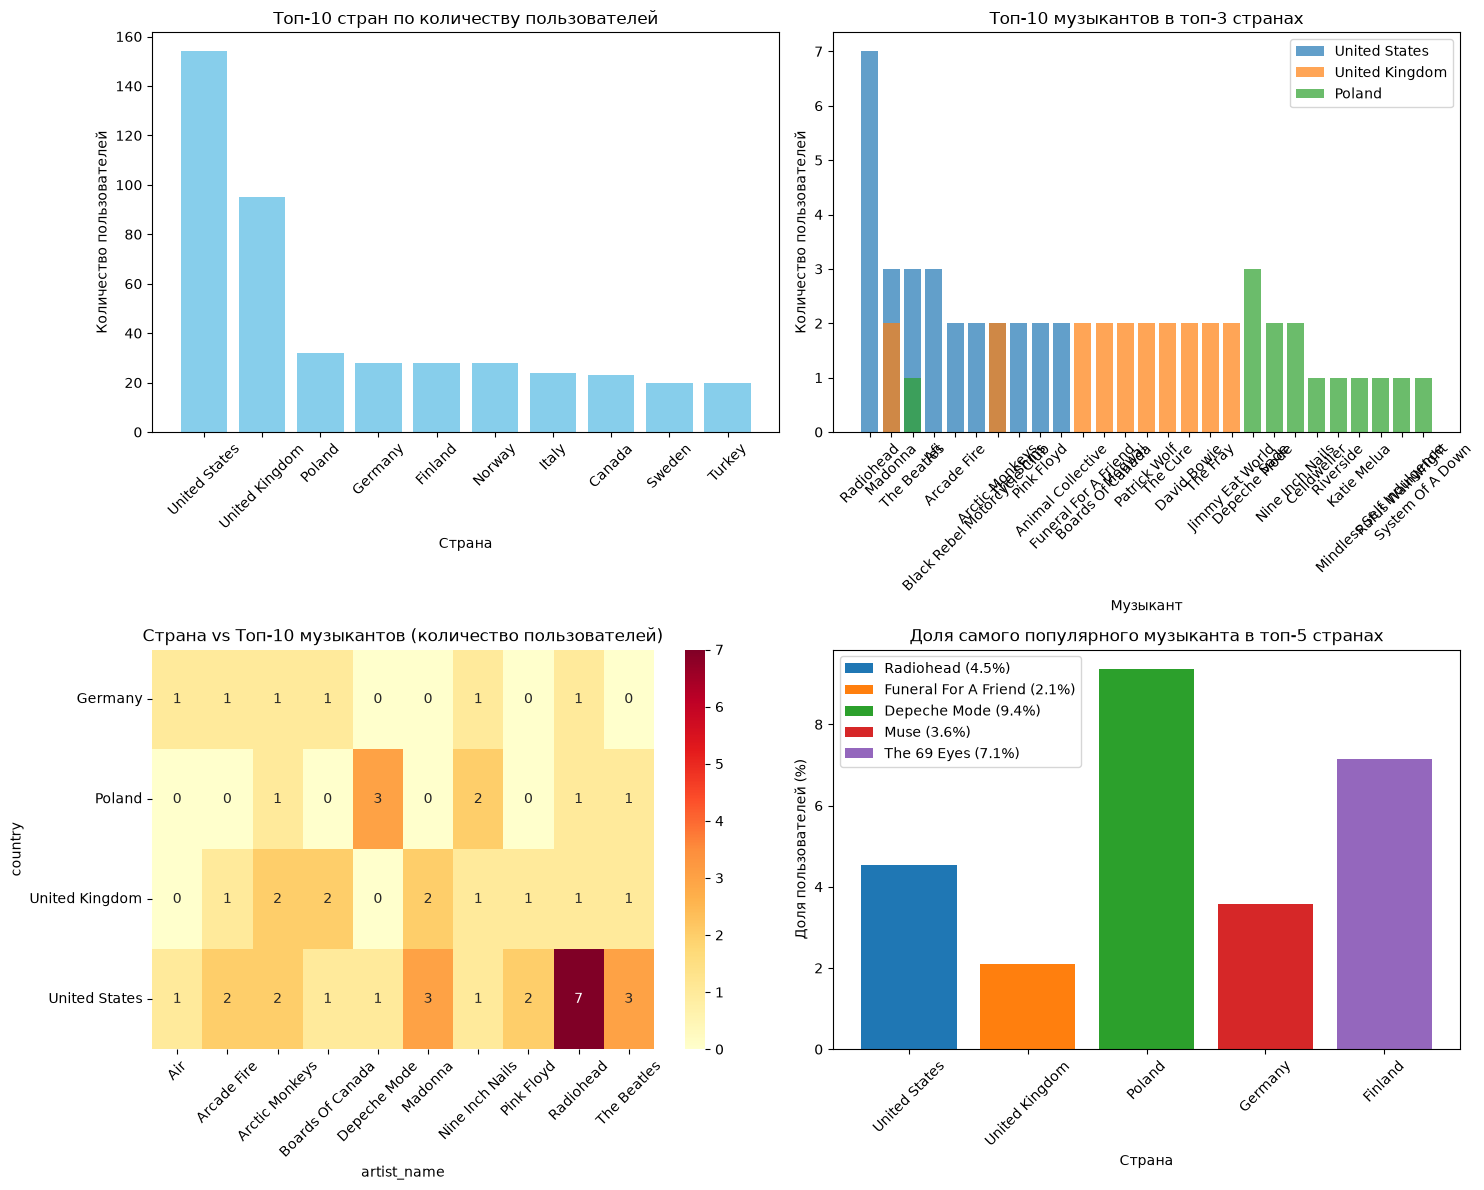


СТАТИСТИЧЕСКИЕ ТЕСТЫ

📊 Тест Хи-квадрат (страна vs топ-5 музыкантов):
  Chi2 = 5.9747
  p-value = 0.2010
  Степени свободы = 4
  ❌ Страна НЕ ВЛИЯЕТ на выбор топ-музыканта (p >= 0.05)

📊 Энтропия (разнообразие) музыкантов по странам:
country
United States     4.785276
United Kingdom    4.407951
Germany           3.332205
Norway            3.332205
Finland           3.282694
Poland            3.276098
Canada            3.135494
Italy             3.040727
Sweden            2.995732
Turkey            2.995732
Name: artist_name, dtype: float64

📊 Пересечение топ-10 музыкантов между странами:
  United States и United Kingdom: 2 общих музыкантов из топ-10
  United States и Poland: 1 общих музыкантов из топ-10
  United States и Germany: 0 общих музыкантов из топ-10
  United States и Finland: 0 общих музыкантов из топ-10
  United Kingdom и Poland: 0 общих музыкантов из топ-10
  United Kingdom и Germany: 1 общих музыкантов из топ-10
  United Kingdom и Finland: 0 общих музыкантов из топ-10
  Pol

In [41]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, f_oneway

# ============================================================
# 1. ЗАГРУЗИ ДАННЫЕ
# ============================================================

# У тебя уже есть df с колонками:
# user_id, artist_name, country, gender, age, track_name

print("Исходные данные:")
print(f"Всего записей (прослушиваний): {len(df)}")
print(f"Уникальных пользователей: {df['user_id'].nunique()}")
print(f"Уникальных музыкантов: {df['artist_name'].nunique()}")

# ============================================================
# 2. ОСТАВЛЯЕМ ТОЛЬКО УНИКАЛЬНЫХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================================

# Для анализа влияния страны на выбор музыканта 
# берем ТОП-3 или ТОП-5 музыкантов каждого пользователя
# или просто первого прослушанного музыканта

# Способ 1: Первый прослушанный музыкант
df_first = df.sort_values('timestamp').drop_duplicates(subset=['user_id'], keep='first')

# Способ 2: Самый часто прослушиваемый музыкант
df_top_artist = df.groupby(['user_id', 'artist_name']).size().reset_index(name='listen_count')
df_top_artist = df_top_artist.sort_values(['user_id', 'listen_count'], ascending=[True, False])
df_top_artist = df_top_artist.drop_duplicates(subset=['user_id'], keep='first')

# Добавляем демографию
df_top_artist = df_top_artist.merge(df[['user_id', 'country', 'gender', 'age']].drop_duplicates('user_id'), on='user_id')

print(f"\nУникальных пользователей (с топ-музыкантом): {len(df_top_artist)}")

# ============================================================
# 3. БАЗОВАЯ СТАТИСТИКА
# ============================================================

print("\n" + "="*70)
print("БАЗОВАЯ СТАТИСТИКА")
print("="*70)

# Количество пользователей по странам
country_counts = df_top_artist['country'].value_counts()
print("\n📊 Распределение пользователей по странам:")
print(country_counts)

# Топ-музыканты по странам
top_artists_by_country = df_top_artist.groupby('country')['artist_name'].value_counts().groupby('country').head(3)
print("\n📊 Топ-3 музыканта по странам:")
print(top_artists_by_country)

# ============================================================
# 4. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 4.1. Топ-10 стран по количеству пользователей
top_countries = country_counts.head(10)
axes[0, 0].bar(top_countries.index, top_countries.values, color='skyblue')
axes[0, 0].set_title('Топ-10 стран по количеству пользователей')
axes[0, 0].set_xlabel('Страна')
axes[0, 0].set_ylabel('Количество пользователей')
axes[0, 0].tick_params(axis='x', rotation=45)

# 4.2. Топ-10 музыкантов в топ-странах
for country in top_countries.index[:3]:
    country_data = df_top_artist[df_top_artist['country'] == country]
    top_artists = country_data['artist_name'].value_counts().head(10)
    axes[0, 1].bar(top_artists.index, top_artists.values, alpha=0.7, label=country)
axes[0, 1].set_title('Топ-10 музыкантов в топ-3 странах')
axes[0, 1].set_xlabel('Музыкант')
axes[0, 1].set_ylabel('Количество пользователей')
axes[0, 1].tick_params(axis='x', rotation=45)
axes[0, 1].legend()

# 4.3. Тепловая карта: страна vs топ-музыкант
top_artists_global = df_top_artist['artist_name'].value_counts().head(10).index
df_heatmap = df_top_artist[df_top_artist['artist_name'].isin(top_artists_global)]
heatmap_data = pd.crosstab(df_heatmap['country'], df_heatmap['artist_name'])

# Оставляем только страны с > 5 пользователями
heatmap_data = heatmap_data[heatmap_data.sum(axis=1) > 5]
sns.heatmap(heatmap_data, annot=True, fmt='d', cmap='YlOrRd', ax=axes[1, 0])
axes[1, 0].set_title('Страна vs Топ-10 музыкантов (количество пользователей)')
axes[1, 0].tick_params(axis='x', rotation=45)
axes[1, 0].tick_params(axis='y', rotation=0)

# 4.4. Доля топ-музыканта в каждой стране
for country in top_countries.index[:5]:
    country_data = df_top_artist[df_top_artist['country'] == country]
    top1 = country_data['artist_name'].value_counts().head(1).index[0]
    top1_share = country_data['artist_name'].value_counts().head(1).values[0] / len(country_data) * 100
    axes[1, 1].bar(country, top1_share, label=f'{top1} ({top1_share:.1f}%)')
axes[1, 1].set_title('Доля самого популярного музыканта в топ-5 странах')
axes[1, 1].set_xlabel('Страна')
axes[1, 1].set_ylabel('Доля пользователей (%)')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# ============================================================
# 5. СТАТИСТИЧЕСКИЕ ТЕСТЫ
# ============================================================

print("\n" + "="*70)
print("СТАТИСТИЧЕСКИЕ ТЕСТЫ")
print("="*70)

# 5.1. Тест Хи-квадрат: страна vs топ-музыкант
top_artists_test = df_top_artist['artist_name'].value_counts().head(5).index
df_test = df_top_artist[df_top_artist['artist_name'].isin(top_artists_test)]
contingency = pd.crosstab(df_test['country'], df_test['artist_name'])

# Оставляем только страны с > 5 пользователями
contingency = contingency[contingency.sum(axis=1) > 5]

if contingency.shape[0] > 1 and contingency.shape[1] > 1:
    chi2, p, dof, expected = chi2_contingency(contingency)
    print(f"\n📊 Тест Хи-квадрат (страна vs топ-5 музыкантов):")
    print(f"  Chi2 = {chi2:.4f}")
    print(f"  p-value = {p:.4f}")
    print(f"  Степени свободы = {dof}")
    
    if p < 0.05:
        print("  ✅ СТРАНА ВЛИЯЕТ на выбор топ-музыканта (p < 0.05)")
    else:
        print("  ❌ Страна НЕ ВЛИЯЕТ на выбор топ-музыканта (p >= 0.05)")

# 5.2. Расчет энтропии (разнообразия)
def shannon_entropy(labels):
    probs = labels.value_counts(normalize=True)
    return -sum(probs * np.log(probs + 1e-10))

entropy_by_country = df_top_artist.groupby('country')['artist_name'].apply(shannon_entropy)
print("\n📊 Энтропия (разнообразие) музыкантов по странам:")
print(entropy_by_country.sort_values(ascending=False).head(10))

# 5.3. Пересечение топ-музыкантов между странами
top_countries = df_top_artist['country'].value_counts().head(5).index
print("\n📊 Пересечение топ-10 музыкантов между странами:")

for i, c1 in enumerate(top_countries):
    for j, c2 in enumerate(top_countries):
        if i < j:
            artists1 = set(df_top_artist[df_top_artist['country'] == c1]['artist_name'].value_counts().head(10).index)
            artists2 = set(df_top_artist[df_top_artist['country'] == c2]['artist_name'].value_counts().head(10).index)
            intersection = len(artists1 & artists2)
            print(f"  {c1} и {c2}: {intersection} общих музыкантов из топ-10")

# ============================================================
# 6. ИТОГОВЫЙ ВЫВОД
# ============================================================

print("\n" + "="*70)
print("ИТОГОВЫЙ ВЫВОД")
print("="*70)

if 'p' in locals():
    if p < 0.05:
        print("✅ СТРАНА ВЛИЯЕТ на выбор музыканта.")
        print("   → Рекомендация: использовать страну как признак в рекомендациях.")
    else:
        print("❌ Страна НЕ ВЛИЯЕТ на выбор музыканта.")
        print("   → Рекомендация: можно не использовать страну как основной признак.")

# Дополнительный вывод
avg_entropy = entropy_by_country.mean()
print(f"\n📊 Средняя энтропия по странам: {avg_entropy:.3f}")
if avg_entropy > 2.0:
    print("   → Высокое разнообразие: внутри стран слушают разных музыкантов")
else:
    print("   → Низкое разнообразие: внутри стран слушают одних и тех же музыкантов")

In [ ]:
import pandas as pd
from src.data_loader import load_dataset

df = load_dataset(year=2007)

# Агрегация
agg = df.groupby(['country', 'artist_name']).agg(
    total_plays=('artist_name', 'size'),
    unique_users=('user_id', 'nunique')
).reset_index()

# Сортируем по странам и популярности
agg_sorted = agg.sort_values(['country', 'total_plays'], ascending=[True, False])

# Для каждой страны — топ-10 исполнителей
top_by_country = agg_sorted.groupby('country').head(10)

print("Страна → Исполнитель → Уникальные пользователи → Всего прослушиваний")
print(top_by_country.to_string(index=False))

Страна → Исполнитель → Уникальные пользователи → Всего прослушиваний
                               country                                      artist_name  unique_users  total_plays
                         United States                                        Radiohead            95         9822
                         United States                                      The Beatles            82         7218
                         United States                                             Beck            81         3216
                         United States                              Death Cab For Cutie            79         5873
                         United States                                      Arcade Fire            77         4416
                         United States                                     Modest Mouse            77         5436
                         United States                                         Coldplay            75         2357
           

In [47]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from src.data_loader import load_dataset

# print("📂 Загрузка данных...")
# df = load_dataset(year=2007)

train_end = '2007-12-24'
df_train = df[df['timestamp'] <= train_end]

# Берём топ-200 исполнителей по частоте (чтобы матрица не взорвалась)
top_artists = df_train['artist_name'].value_counts().head(200).index.tolist()

# Строим матрицу user-artist (только для топ-200 исполнителей)
user_artist = df_train[df_train['artist_name'].isin(top_artists)].groupby(
    ['user_id', 'artist_name']
).size().unstack(fill_value=0)

# Нормализуем (TF-IDF или просто L2)
from sklearn.preprocessing import normalize
artist_matrix = normalize(user_artist.T, norm='l2')  # Транспонируем, чтобы строки = исполнители

# Считаем косинусную схожесть между исполнителями
artist_similarity = cosine_similarity(artist_matrix)

# Переводим в DataFrame
artist_names = user_artist.columns.tolist()
artist_sim_df = pd.DataFrame(
    artist_similarity,
    index=artist_names,
    columns=artist_names
)

# Для каждого исполнителя — топ-5 похожих
print("\n🎵 Топ-5 похожих исполнителей:")
for artist in artist_names[:10]:  # Первые 10 для примера
    similar = artist_sim_df[artist].sort_values(ascending=False).iloc[1:6]  # без самого себя
    print(f"\n{artist}:")
    for name, score in similar.items():
        print(f"  {score:.3f} — {name}")

# # Сохраняем матрицу
# artist_sim_df.to_csv('data/artist_similarity.csv')
# print("\n✅ Матрица сохранена в data/artist_similarity.csv")


🎵 Топ-5 похожих исполнителей:

30 Seconds To Mars:
  0.614 — Justin Timberlake
  0.595 — My Chemical Romance
  0.526 — Avril Lavigne
  0.511 — Afi
  0.475 — Muse

A Perfect Circle:
  0.639 — Katatonia
  0.570 — Anathema
  0.437 — Tool
  0.420 — Fiona Apple
  0.380 — Porcupine Tree

Ac/Dc:
  0.637 — Disturbed
  0.634 — Soilwork
  0.634 — Sonic Syndicate
  0.541 — Children Of Bodom
  0.541 — Megadeth

Afi:
  0.511 — 30 Seconds To Mars
  0.386 — Katatonia
  0.381 — The Smashing Pumpkins
  0.354 — Avril Lavigne
  0.351 — My Chemical Romance

Air:
  0.560 — Moby
  0.478 — Röyksopp
  0.388 — Daft Punk
  0.274 — Zero 7
  0.274 — Gorillaz

Alanis Morissette:
  0.713 — Garbage
  0.705 — Evanescence
  0.656 — Tori Amos
  0.618 — Fiona Apple
  0.593 — Nine Inch Nails

Amorphis:
  0.823 — Soilwork
  0.802 — Sonic Syndicate
  0.801 — Disturbed
  0.775 — Children Of Bodom
  0.630 — Megadeth

Amy Winehouse:
  0.254 — Nelly Furtado
  0.249 — My Chemical Romance
  0.247 — Mika
  0.234 — Justin Timberl

In [48]:
import pandas as pd
from src.data_loader import load_dataset

# df = load_dataset(year=2007)

train_end = '2007-12-24'
test_start = '2007-12-25'

df_train = df[df['timestamp'] <= train_end]
df_test = df[df['timestamp'] >= test_start]

# ========================================
# 1. Топ-3 пользователя по прослушиваниям (train)
# ========================================
user_plays_train = df_train.groupby('user_id').size().sort_values(ascending=False)
print("🏆 Топ-3 пользователя по прослушиваниям (train):")
for i, (user, count) in enumerate(user_plays_train.head(3).items(), 1):
    print(f"  {i}. {user}: {count} прослушиваний")

# ========================================
# 2. Топ-10 исполнителей в train
# ========================================
artist_train = df_train.groupby('artist_name').size().sort_values(ascending=False)
print("\n🎵 Топ-10 исполнителей (train):")
for i, (artist, count) in enumerate(artist_train.head(10).items(), 1):
    print(f"  {i}. {artist}: {count}")

# ========================================
# 3. Топ-10 исполнителей в test
# ========================================
artist_test = df_test.groupby('artist_name').size().sort_values(ascending=False)
print("\n🎵 Топ-10 исполнителей (test):")
for i, (artist, count) in enumerate(artist_test.head(10).items(), 1):
    print(f"  {i}. {artist}: {count}")

# ========================================
# 4. Пересечение топ-10 train и test
# ========================================
top_train = set(artist_train.head(10).index)
top_test = set(artist_test.head(10).index)
overlap = top_train & top_test
print(f"\n🔗 Пересечение топ-10 (train ∩ test): {len(overlap)} из 10")
if overlap:
    print(f"  Общие: {', '.join(list(overlap)[:5])}")

🏆 Топ-3 пользователя по прослушиваниям (train):
  1. user_000691: 53986 прослушиваний
  2. user_000155: 50029 прослушиваний
  3. user_000544: 44298 прослушиваний

🎵 Топ-10 исполнителей (train):
  1. Radiohead: 29206
  2. The Beatles: 25931
  3. The Knife: 20442
  4. Nine Inch Nails: 17498
  5. Pink Floyd: 17113
  6. Arcade Fire: 15434
  7. Muse: 14670
  8. Interpol: 14452
  9. Depeche Mode: 14395
  10. Björk: 14022

🎵 Топ-10 исполнителей (test):
  1. The Doors: 963
  2. Radiohead: 682
  3. The Beatles: 609
  4. Daft Punk: 495
  5. The Jesus And Mary Chain: 458
  6. Placebo: 423
  7. Icehouse: 383
  8. Depeche Mode: 334
  9. David Bowie: 327
  10. Black Rebel Motorcycle Club: 319

🔗 Пересечение топ-10 (train ∩ test): 3 из 10
  Общие: Depeche Mode, The Beatles, Radiohead


🔍 Супер-пользователь: user_000691
📊 Всего прослушиваний: 54819

📅 Период: 2007-05-28 13:30:11 -> 2007-12-29 19:14:05
📆 Дней в периоде: 215

📊 СТАТИСТИКА ПО ДНЯМ:
  Среднее в день: 285.5
  Медиана в день: 330
  Максимум в день: 363
  Минимум в день: 1
  Дней с прослушиваниями: 192

📊 СТАТИСТИКА ПО МЕСЯЦАМ:
year_month
2007-05     1195
2007-06     4801
2007-07     6017
2007-08    10060
2007-09     9990
2007-10     9459
2007-11     7285
2007-12     6012
Freq: M, dtype: int64

🔍 ПРОВЕРКА НА АНОМАЛИИ:
  ✅ Аномалий не найдено.
  ✅ Максимальное количество за день (363) выглядит реалистично.


TypeError: Axes.boxplot() got an unexpected keyword argument 'labels'

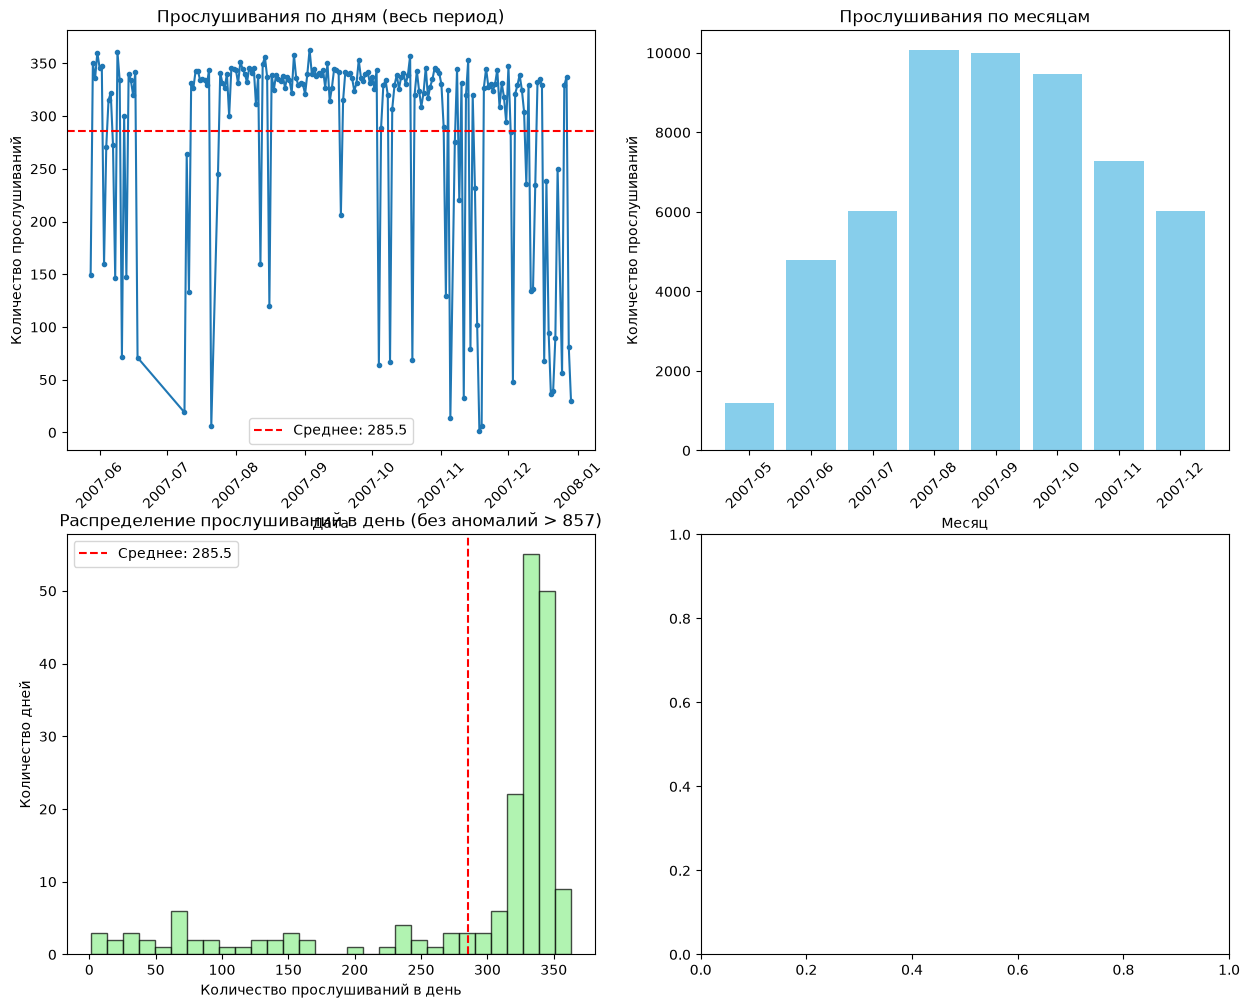

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Предполагаем, что у тебя есть df с колонками: user_id, timestamp

# ============================================================
# 1. ПРЕОБРАЗУЙ ТАЙМСТАМП В ДАТУ
# ============================================================

# Если timestamp в секундах (Unix)
df['date'] = pd.to_datetime(df['timestamp'], unit='s')

# Если timestamp уже в формате datetime:
# df['date'] = pd.to_datetime(df['timestamp'])

# Добавляем месяц и день
df['year_month'] = df['date'].dt.to_period('M')
df['date_only'] = df['date'].dt.date

# ============================================================
# 2. НАЙДИ СУПЕР-ПОЛЬЗОВАТЕЛЯ
# ============================================================

# Количество прослушиваний на пользователя
user_listens = df.groupby('user_id').size().sort_values(ascending=False)
super_user_id = user_listens.idxmax()

print(f"🔍 Супер-пользователь: {super_user_id}")
print(f"📊 Всего прослушиваний: {user_listens.max()}")

# ============================================================
# 3. ДАННЫЕ ТОЛЬКО ПО СУПЕР-ПОЛЬЗОВАТЕЛЮ
# ============================================================

super_user_df = df[df['user_id'] == super_user_id].copy()
super_user_df = super_user_df.sort_values('date')

print(f"\n📅 Период: {super_user_df['date'].min()} -> {super_user_df['date'].max()}")
print(f"📆 Дней в периоде: {(super_user_df['date'].max() - super_user_df['date'].min()).days}")

# ============================================================
# 4. РАСПРЕДЕЛЕНИЕ ПО ДНЯМ И МЕСЯЦАМ
# ============================================================

# Количество прослушиваний по дням
daily_listens = super_user_df.groupby('date_only').size()
monthly_listens = super_user_df.groupby('year_month').size()

print("\n📊 СТАТИСТИКА ПО ДНЯМ:")
print(f"  Среднее в день: {daily_listens.mean():.1f}")
print(f"  Медиана в день: {daily_listens.median():.0f}")
print(f"  Максимум в день: {daily_listens.max()}")
print(f"  Минимум в день: {daily_listens.min()}")
print(f"  Дней с прослушиваниями: {len(daily_listens)}")

print("\n📊 СТАТИСТИКА ПО МЕСЯЦАМ:")
print(monthly_listens)

# ============================================================
# 5. ПРОВЕРКА НА АНОМАЛИИ
# ============================================================

print("\n🔍 ПРОВЕРКА НА АНОМАЛИИ:")

# Дни с аномально большим количеством прослушиваний (> 3 * среднее)
avg_daily = daily_listens.mean()
threshold = avg_daily * 3
anomaly_days = daily_listens[daily_listens > threshold]

if len(anomaly_days) > 0:
    print(f"  ⚠️ Найдены дни с аномально большим числом прослушиваний (> {threshold:.0f}):")
    print(anomaly_days)
else:
    print("  ✅ Аномалий не найдено.")

# Проверка: не было ли 50K за один день?
if daily_listens.max() > 10000:
    print(f"  🚨 ВНИМАНИЕ! За один день было {daily_listens.max()} прослушиваний — это похоже на ошибку!")
elif daily_listens.max() > 2000:
    print(f"  ⚠️ За один день было {daily_listens.max()} прослушиваний — это возможно, но маловероятно для обычного пользователя.")
else:
    print(f"  ✅ Максимальное количество за день ({daily_listens.max()}) выглядит реалистично.")

# ============================================================
# 6. ВИЗУАЛИЗАЦИЯ
# ============================================================

fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# График 1: Прослушивания по дням (весь период)
axes[0, 0].plot(daily_listens.index, daily_listens.values, marker='o', linestyle='-', markersize=3)
axes[0, 0].axhline(y=avg_daily, color='r', linestyle='--', label=f'Среднее: {avg_daily:.1f}')
axes[0, 0].set_title('Прослушивания по дням (весь период)')
axes[0, 0].set_xlabel('Дата')
axes[0, 0].set_ylabel('Количество прослушиваний')
axes[0, 0].legend()
axes[0, 0].tick_params(axis='x', rotation=45)

# График 2: Прослушивания по месяцам
axes[0, 1].bar(monthly_listens.index.astype(str), monthly_listens.values, color='skyblue')
axes[0, 1].set_title('Прослушивания по месяцам')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Количество прослушиваний')
axes[0, 1].tick_params(axis='x', rotation=45)

# График 3: Гистограмма распределения по дням (без аномалий)
daily_no_anomaly = daily_listens[daily_listens <= threshold]
axes[1, 0].hist(daily_no_anomaly, bins=30, edgecolor='black', alpha=0.7, color='lightgreen')
axes[1, 0].axvline(x=avg_daily, color='r', linestyle='--', label=f'Среднее: {avg_daily:.1f}')
axes[1, 0].set_title(f'Распределение прослушиваний в день (без аномалий > {threshold:.0f})')
axes[1, 0].set_xlabel('Количество прослушиваний в день')
axes[1, 0].set_ylabel('Количество дней')
axes[1, 0].legend()

# График 4: Boxplot по месяцам
monthly_data = [super_user_df[super_user_df['year_month'] == m]['date_only'].value_counts().values 
                for m in monthly_listens.index]
axes[1, 1].boxplot(monthly_data, labels=monthly_listens.index.astype(str))
axes[1, 1].set_title('Распределение прослушиваний по месяцам (boxplot)')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Количество прослушиваний в день')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# ============================================================
# 7. ФИНАЛЬНАЯ ПРОВЕРКА
# ============================================================

print("\n" + "="*70)
print("ИТОГОВАЯ ПРОВЕРКА")
print("="*70)

if daily_listens.max() > 10000:
    print("🚨 СКОРЕЕ ВСЕГО, ЭТО ОШИБКА В ДАННЫХ!")
    print("   За один день было более 10 000 прослушиваний — это невозможно для реального пользователя.")
    print("   Рекомендация: удалить этого пользователя из датасета для анализа.")
elif daily_listens.max() > 2000:
    print("⚠️ ВОЗМОЖНО, ЭТО ОШИБКА ИЛИ БОТ.")
    print("   За один день было более 2 000 прослушиваний — это крайне много.")
    print("   Проверьте данные на наличие дубликатов или багов.")
else:
    print("✅ Данные выглядят реалистично.")
    print(f"   Среднее: {avg_daily:.1f} прослушиваний в день.")
    print(f"   Максимум: {daily_listens.max()} прослушиваний в день.")
    print("   Это может быть реальный активный пользователь.")

In [51]:
df[df['user_id']=='user_000691'].head(1)

,user_index,artist_index,track_index,user_id,timestamp,musicbrainz_artist_id,artist_name,musicbrainz_track_id,track_name,gender,age,country,signup_date,date,year_month,date_only
8873919,683,58039,362224,user_000691,2007-12-29 19:14:05,b10bbbfc-cf9e-42e0-be17-e2c3e1d2600d,The Beatles,60acf91d-62e8-4476-81ce-2b856faeabb1,Nowhere Man,male,NaN,United States,2006-06-30,2007-12-29 19:14:05,2007-12,2007-12-29


✅ Матрица сжата: (721, 5000)
   Пользователей: 721
   Исполнителей: 5000
Матрица профилей: (721, 5000)
Пользователей: 721
Исполнителей: 5000

⏳ Считаем попарное сходство...
✅ Матрица сходства: (721, 721)
user_id      user_000001  user_000002  user_000003  user_000004  user_000005  \
user_id                                                                        
user_000001     1.000000     0.008461     0.005178     0.299864     0.019660   
user_000002     0.008461     1.000000     0.041769     0.050156     0.018905   
user_000003     0.005178     0.041769     1.000000     0.020033     0.098267   
user_000004     0.299864     0.050156     0.020033     1.000000     0.066108   
user_000005     0.019660     0.018905     0.098267     0.066108     1.000000   

user_id      user_000006  user_000007  user_000009  user_000010  user_000011  \
user_id                                                                        
user_000001     0.025855     0.000543     0.000000     0.000000     0.00000

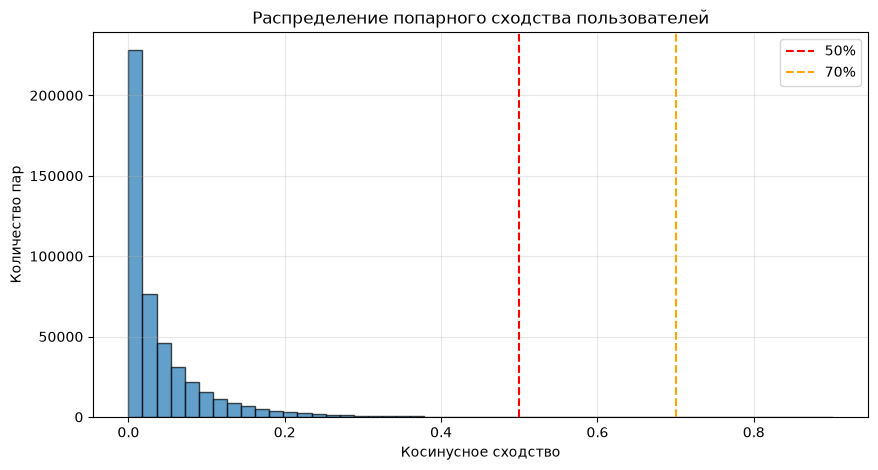

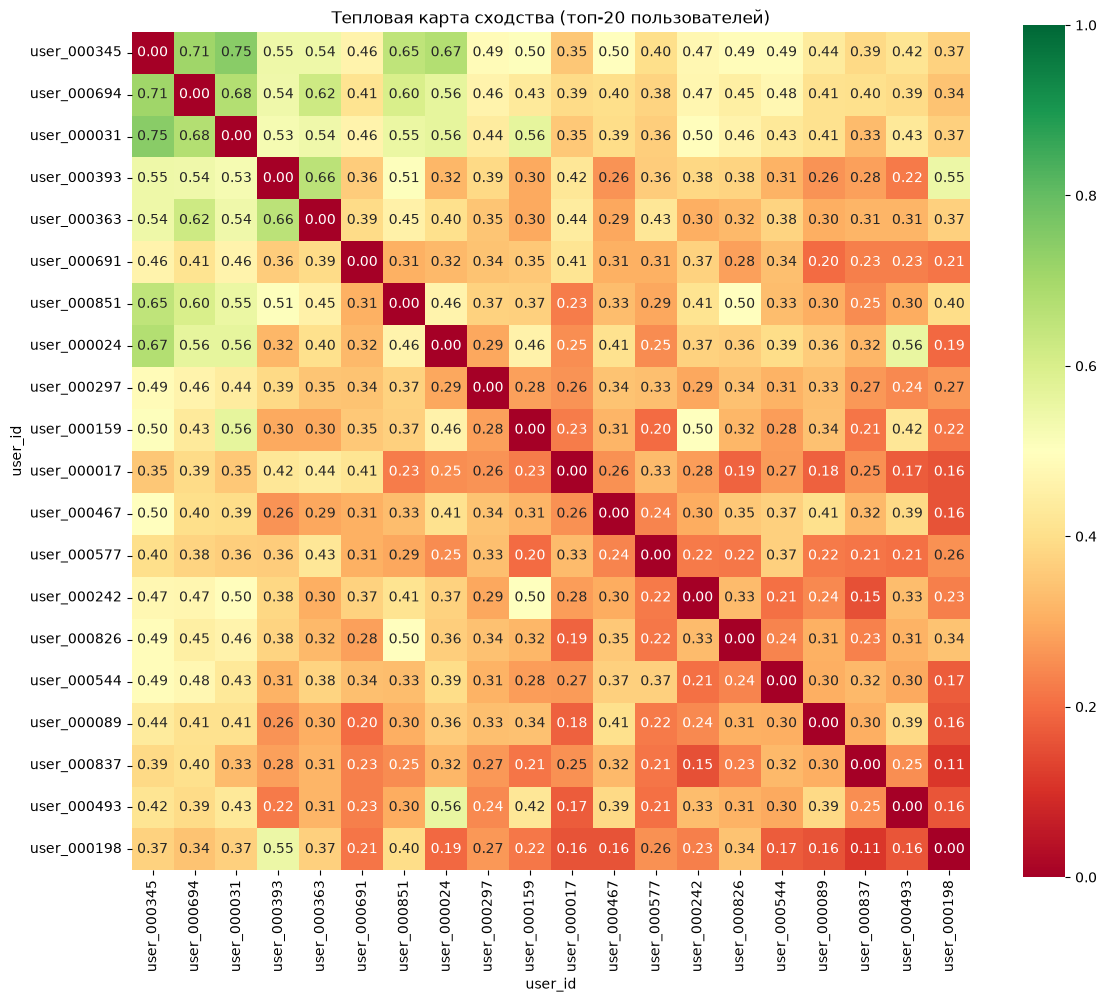


САМАЯ ПОХОЖАЯ ПАРА
👤 user_000044 и 👤 user_000115
   Сходство: 0.9013 (90.1%)

   user_000044 (топ-5):
     - Him: 36.7%
     - Savage Garden: 5.4%
     - Within Temptation: 5.0%
     - Blackmore'S Night: 4.3%
     - Nightwish: 3.0%

   user_000115 (топ-5):
     - Him: 18.4%
     - Entwine: 3.0%
     - Keane: 2.1%
     - Evanescence: 1.8%
     - The 69 Eyes: 1.8%

   Прослушиваний: user_000044 = 3766, user_000115 = 337


In [60]:
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

# 1. Строим матрицу "пользователь × исполнитель" (сырые счетчики)
user_artist_matrix = df.groupby(['user_id', 'artist_name']).size().unstack(fill_value=0)

# Топ-5000 исполнителей (по популярности)
artist_counts = df['artist_name'].value_counts()
top_artists = artist_counts.head(5000).index

# Уменьшаем матрицу
user_artist_matrix_top = user_artist_matrix[top_artists]

print(f"✅ Матрица сжата: {user_artist_matrix_top.shape}")
print(f"   Пользователей: {user_artist_matrix_top.shape[0]}")
print(f"   Исполнителей: {user_artist_matrix_top.shape[1]}")

# Нормализуем по строкам (сумма = 1)
user_profile_top = user_artist_matrix_top.div(user_artist_matrix_top.sum(axis=1), axis=0)
user_profile_top = user_profile_top.fillna(0)
import pandas as pd
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. УБЕДИСЬ, ЧТО ПРОФИЛИ ГОТОВЫ
# ============================================================

# user_profile_top — матрица user × artist (доли)
print(f"Матрица профилей: {user_profile_top.shape}")
print(f"Пользователей: {user_profile_top.shape[0]}")
print(f"Исполнителей: {user_profile_top.shape[1]}")

# ============================================================
# 2. СЧИТАЕМ МАТРИЦУ СХОДСТВА (ВСЕХ СО ВСЕМИ)
# ============================================================

print("\n⏳ Считаем попарное сходство...")

# Так как матрица большая (721 × 5000), считаем косинусное сходство
# Это займет 1-2 минуты
similarity_matrix = cosine_similarity(user_profile_top)

# Превращаем в DataFrame для удобства
similarity_df = pd.DataFrame(
    similarity_matrix,
    index=user_profile_top.index,
    columns=user_profile_top.index
)

print(f"✅ Матрица сходства: {similarity_df.shape}")
print(similarity_df.head())

# ============================================================
# 3. НАХОДИМ ПАРЫ ПОХОЖИХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================================

# Убираем диагональ (сходство с самим собой = 1)
np.fill_diagonal(similarity_matrix, 0)

# Находим топ-10 самых похожих пар
# Превращаем матрицу в список пар
pairs = []
for i in range(len(similarity_matrix)):
    for j in range(i+1, len(similarity_matrix)):
        if similarity_matrix[i][j] > 0.5:  # порог 50%
            pairs.append({
                'user1': user_profile_top.index[i],
                'user2': user_profile_top.index[j],
                'similarity': similarity_matrix[i][j]
            })

# Сортируем по убыванию сходства
pairs_df = pd.DataFrame(pairs).sort_values('similarity', ascending=False)

print(f"\n🔍 Найдено пар со сходством > 50%: {len(pairs_df)}")
print(pairs_df.head(10))

# ============================================================
# 4. СТАТИСТИКА ПО СХОДСТВУ
# ============================================================

# Все значения сходства (без диагонали)
all_similarities = similarity_matrix[similarity_matrix > 0]

print("\n📊 СТАТИСТИКА ПО СХОДСТВУ:")
print(f"  Среднее: {all_similarities.mean():.4f}")
print(f"  Медиана: {np.median(all_similarities):.4f}")
print(f"  Максимум: {all_similarities.max():.4f}")
print(f"  Минимум: {all_similarities.min():.4f}")

# Распределение сходства
plt.figure(figsize=(10, 5))
plt.hist(all_similarities, bins=50, edgecolor='black', alpha=0.7)
plt.axvline(x=0.5, color='r', linestyle='--', label='50%')
plt.axvline(x=0.7, color='orange', linestyle='--', label='70%')
plt.xlabel('Косинусное сходство')
plt.ylabel('Количество пар')
plt.title('Распределение попарного сходства пользователей')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

# ============================================================
# 5. ВИЗУАЛИЗАЦИЯ: ТЕПЛОВАЯ КАРТА (ТОП-20 ПОХОЖИХ)
# ============================================================

# Берем топ-20 пользователей с самым высоким средним сходством
avg_similarity = similarity_df.mean(axis=1).sort_values(ascending=False)
top_users = avg_similarity.head(20).index

# Тепловая карта для топ-20
plt.figure(figsize=(12, 10))
sns.heatmap(
    similarity_df.loc[top_users, top_users],
    annot=True,
    fmt='.2f',
    cmap='RdYlGn',
    vmin=0,
    vmax=1,
    square=True
)
plt.title('Тепловая карта сходства (топ-20 пользователей)')
plt.tight_layout()
plt.show()

# ============================================================
# 6. ПРОФИЛИ САМЫХ ПОХОЖИХ ПОЛЬЗОВАТЕЛЕЙ
# ============================================================

if len(pairs_df) > 0:
    # Берем первую пару (самых похожих)
    user1 = pairs_df.iloc[0]['user1']
    user2 = pairs_df.iloc[0]['user2']
    sim = pairs_df.iloc[0]['similarity']
    
    print("\n" + "="*70)
    print(f"САМАЯ ПОХОЖАЯ ПАРА")
    print("="*70)
    print(f"👤 {user1} и 👤 {user2}")
    print(f"   Сходство: {sim:.4f} ({sim*100:.1f}%)")
    
    # Топ-5 исполнителей у каждого
    profile1 = user_profile_top.loc[user1].sort_values(ascending=False).head(5)
    profile2 = user_profile_top.loc[user2].sort_values(ascending=False).head(5)
    
    print(f"\n   {user1} (топ-5):")
    for artist, share in profile1.items():
        if share > 0:
            print(f"     - {artist}: {share*100:.1f}%")
    
    print(f"\n   {user2} (топ-5):")
    for artist, share in profile2.items():
        if share > 0:
            print(f"     - {artist}: {share*100:.1f}%")
    
    # Сколько прослушиваний у каждого
    listens1 = user_artist_matrix_top.loc[user1].sum()
    listens2 = user_artist_matrix_top.loc[user2].sum()
    print(f"\n   Прослушиваний: {user1} = {listens1}, {user2} = {listens2}")